# WandB Confidence Analysis - First vs Last Task Comparison

첫 번째 Task와 마지막 Task의 modality별 confidence 비교 분석

- Generated: 2025-10-14 16:27:20
- Dataset: UESTC-MMEA-CL
- Total Classes: 32
- Total Tasks: 8

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 임포트 완료')

✅ 라이브러리 임포트 완료


## 2. Class Mapping & Order Definition

In [2]:
class_to_activity = {
    0: "upstairs", 1: "downstairs", 2: "drinking", 3: "fall",
    4: "reading", 5: "sweep-floor", 6: "cut-fruits", 7: "mop-floor",
    8: "writing", 9: "wipe-table", 10: "wash-hand", 11: "standing",
    12: "play-phone", 13: "type-PC", 14: "eating", 15: "cooking",
    16: "pick-up-phone", 17: "drop-trash", 18: "fold-clothes", 19: "walking",
    20: "play-card", 21: "brush-teeth", 22: "wash-dish", 23: "moving-sth",
    24: "type-phone", 25: "chat", 26: "open-close-door", 27: "ride-bike",
    28: "sit-stand", 29: "take-drop-sth", 30: "shopping", 31: "watch-TV"
}

UESTC_MMEA_CLASS_ORDER = [
    26, 14, 23, 4, 11, 25, 31, 10,
    29, 5, 6, 9, 17, 22, 2, 19,
    13, 1, 21, 16, 8, 3, 27, 28,
    15, 30, 0, 7, 12, 18, 20, 24
]

print(f'✅ Class 매핑 완료: {len(class_to_activity)}개 클래스')

✅ Class 매핑 완료: 32개 클래스


In [3]:
import wandb

# WandB API로 데이터 불러오기
api = wandb.Api()

# Run ID 설정 (필요시 변경)
# v5: 2t24jgye
#
# v2 (code: v2_7)
    # pretrain_epochs: 50 => 3ll7nusq 
    # pretrain_epochs: 10 => xz343jq1 
# v3 (code: v2_8)
    # pretrain_epochs: 50 => wtt0681q 
    # pretrain_epochs: 10 => dzwhbjuj
run = api.run("/mmea-owcl/Experimental Results on the MMEA-OWCL (CL Training & Evaluation)/runs/xz343jq1")

# entropy: sdgtl402
# energy: 86k2murh
# margin: 29lefk81
# variance: m1fft7wu
# doctor: a3u1ayhc
# v2_10: wnn3qn0z

# v3
    # entropy: gsvyef2g
# run = api.run("/mmea-owcl/MMEA-OWCL_hj_test/runs/wnn3qn0z")

# History 데이터 가져오기
history = run.history()

print(f'✅ WandB 데이터 로드 완료')
print(f'   History shape: {history.shape}')
print(f'   총 컬럼 수: {len(history.columns)}')

✅ WandB 데이터 로드 완료
   History shape: (440, 800)
   총 컬럼 수: 800


In [4]:
# ClassConfidence + mean만 필터링
classconf_mean_columns = [col for col in history.columns 
                          if 'ClassConfidence' in col and '_mean' in col]

df_classconf_mean = history[classconf_mean_columns].copy()

print("="*80)
print("ClassConfidence mean 컬럼 필터링 완료")
print("="*80)
print(f"ClassConfidence mean만: {df_classconf_mean.shape}")

# 첫 몇 개 컬럼 확인
print(f"\n처음 10개 컬럼:")
for i, col in enumerate(df_classconf_mean.columns[:10], 1):
    print(f"  {i}. {col}")

ClassConfidence mean 컬럼 필터링 완료
ClassConfidence mean만: (440, 384)

처음 10개 컬럼:
  1. ClassConfidence/TEST_class5_RGB_mean
  2. ClassConfidence/FROZEN_class16_Gyro_mean
  3. ClassConfidence/END_class22_Acce_mean
  4. ClassConfidence/END_class17_Gyro_mean
  5. ClassConfidence/START_class3_RGB_mean
  6. ClassConfidence/TEST_class22_Gyro_mean
  7. ClassConfidence/START_class7_Acce_mean
  8. ClassConfidence/FROZEN_class21_Acce_mean
  9. ClassConfidence/FROZEN_class15_RGB_mean
  10. ClassConfidence/FROZEN_class1_Gyro_mean


In [5]:
# State별로 DataFrame 분리
df_start = df_classconf_mean[[col for col in df_classconf_mean.columns if '/START_' in col]].copy()
df_frozen = df_classconf_mean[[col for col in df_classconf_mean.columns if '/FROZEN_' in col]].copy()
df_end = df_classconf_mean[[col for col in df_classconf_mean.columns if '/END_' in col]].copy()
df_test = df_classconf_mean[[col for col in df_classconf_mean.columns if '/TEST_' in col]].copy()

print("="*80)
print("State별 DataFrame 분리 완료")
print("="*80)
print(f"\n1. df_start:  {df_start.shape}  - START 상태 (Task 시작)")
print(f"2. df_frozen: {df_frozen.shape} - FROZEN 상태 (과거 class들)")
print(f"3. df_end:    {df_end.shape}    - END 상태 (학습 완료)")
print(f"4. df_test:   {df_test.shape}   - TEST 상태 (테스트)")

# 각 DataFrame의 컬럼 개수 확인
print(f"\n컬럼 수:")
print(f"  START:  {len(df_start.columns)}개")
print(f"  FROZEN: {len(df_frozen.columns)}개")
print(f"  END:    {len(df_end.columns)}개")
print(f"  TEST:   {len(df_test.columns)}개")

State별 DataFrame 분리 완료

1. df_start:  (440, 96)  - START 상태 (Task 시작)
2. df_frozen: (440, 96) - FROZEN 상태 (과거 class들)
3. df_end:    (440, 96)    - END 상태 (학습 완료)
4. df_test:   (440, 96)   - TEST 상태 (테스트)

컬럼 수:
  START:  96개
  FROZEN: 96개
  END:    96개
  TEST:   96개


## 5. Data Cleaning

In [6]:
print("="*80)
print("NaN 제외된 DataFrame 생성 (Step-by-Step)")
print("="*80)

print("\n📌 STEP 0: 원본 데이터 (df_start)")
print("-"*80)
print(f"Shape: {df_start.shape}")
print(f"Total elements: {df_start.shape[0] * df_start.shape[1]}")
print(f"NaN count: {df_start.isna().sum().sum()}")
print(f"Non-NaN count: {df_start.notna().sum().sum()}")

# 처음 5개 행, 5개 열만 출력
print(f"\n원본 데이터 샘플 (처음 5행 x 5열):")
print(df_start.iloc[:5, :5])

print("\n" + "="*80)
print("📌 STEP 1: 모든 값이 NaN인 행(row) 제거")
print("-"*80)

# Step 1: 모든 값이 NaN인 행 제거
df_start_step1 = df_start.dropna(how='all').copy()
print(f"Shape: {df_start.shape} → {df_start_step1.shape}")
print(f"제거된 행 수: {df_start.shape[0] - df_start_step1.shape[0]}")

# 어떤 행이 NaN인지 확인
all_nan_rows = df_start.isna().all(axis=1)
print(f"\n모든 값이 NaN인 행:")
if all_nan_rows.sum() > 0:
    nan_row_indices = all_nan_rows[all_nan_rows].index.tolist()
    print(f"  인덱스: {nan_row_indices[:10]}..." if len(nan_row_indices) > 10 else f"  인덱스: {nan_row_indices}")
else:
    print("  없음")

print("\n" + "="*80)
print("📌 STEP 2: 모든 값이 NaN인 열(column) 제거")
print("-"*80)

# Step 2: 모든 값이 NaN인 열 제거
df_start_clean = df_start_step1.dropna(axis=1, how='all')
print(f"Shape: {df_start_step1.shape} → {df_start_clean.shape}")
print(f"제거된 열 수: {df_start_step1.shape[1] - df_start_clean.shape[1]}")

# 어떤 열이 NaN인지 확인
all_nan_cols = df_start_step1.isna().all(axis=0)
print(f"\n모든 값이 NaN인 열:")
if all_nan_cols.sum() > 0:
    nan_col_names = all_nan_cols[all_nan_cols].index.tolist()
    print(f"  개수: {len(nan_col_names)}")
    print(f"  예시: {nan_col_names[:5]}..." if len(nan_col_names) > 5 else f"  전체: {nan_col_names}")
else:
    print("  없음")

print("\n" + "="*80)
print("📌 최종 결과: df_start_clean")
print("-"*80)
print(f"Shape: {df_start_clean.shape}")
print(f"Total elements: {df_start_clean.shape[0] * df_start_clean.shape[1]}")
print(f"NaN count: {df_start_clean.isna().sum().sum()}")
print(f"Non-NaN count: {df_start_clean.notna().sum().sum()}")
print(f"NaN 비율: {df_start_clean.isna().sum().sum() / (df_start_clean.shape[0] * df_start_clean.shape[1]) * 100:.2f}%")

print(f"\n정리된 데이터 샘플 (처음 5행 x 5열):")
print(df_start_clean.iloc[:5, :min(5, df_start_clean.shape[1])])

print("\n" + "="*80)
print("📊 각 State별 요약")
print("="*80)

# 다른 State도 동일하게 처리
df_frozen_clean = df_frozen.dropna(how='all').copy().dropna(axis=1, how='all')
df_end_clean = df_end.dropna(how='all').copy().dropna(axis=1, how='all')
df_test_clean = df_test.dropna(how='all').copy().dropna(axis=1, how='all')

states_summary = [
    ('START', df_start, df_start_clean),
    ('FROZEN', df_frozen, df_frozen_clean),
    ('END', df_end, df_end_clean),
    ('TEST', df_test, df_test_clean)
]

for state_name, df_orig, df_clean in states_summary:
    orig_rows, orig_cols = df_orig.shape
    clean_rows, clean_cols = df_clean.shape
    removed_rows = orig_rows - clean_rows
    removed_cols = orig_cols - clean_cols
    
    print(f"\n{state_name}:")
    print(f"  원본:     {orig_rows:4d} rows x {orig_cols:4d} cols = {orig_rows * orig_cols:6d} elements")
    print(f"  정리됨:   {clean_rows:4d} rows x {clean_cols:4d} cols = {clean_rows * clean_cols:6d} elements")
    print(f"  제거됨:   {removed_rows:4d} rows,  {removed_cols:4d} cols")
    
    if clean_rows > 0 and clean_cols > 0:
        nan_ratio = df_clean.isna().sum().sum() / (clean_rows * clean_cols) * 100
        print(f"  남은 NaN: {df_clean.isna().sum().sum():6d} ({nan_ratio:.1f}%)")

NaN 제외된 DataFrame 생성 (Step-by-Step)

📌 STEP 0: 원본 데이터 (df_start)
--------------------------------------------------------------------------------
Shape: (440, 96)
Total elements: 42240
NaN count: 41808
Non-NaN count: 432

원본 데이터 샘플 (처음 5행 x 5열):
   ClassConfidence/START_class3_RGB_mean  \
0                               0.257302   
1                                    NaN   
2                                    NaN   
3                                    NaN   
4                                    NaN   

   ClassConfidence/START_class7_Acce_mean  \
0                                     NaN   
1                                     NaN   
2                                     NaN   
3                                     NaN   
4                                     NaN   

   ClassConfidence/START_class23_RGB_mean  \
0                                     NaN   
1                                     NaN   
2                                     NaN   
3                                     

In [7]:
print("="*80)
print("NaN 제외된 DataFrame 생성")
print("="*80)

df_start_clean = df_start.dropna(how='all').copy().dropna(axis=1, how='all')
df_frozen_clean = df_frozen.dropna(how='all').copy().dropna(axis=1, how='all')
df_end_clean = df_end.dropna(how='all').copy().dropna(axis=1, how='all')
df_test_clean = df_test.dropna(how='all').copy().dropna(axis=1, how='all')

print(f"START:  {df_start.shape} → {df_start_clean.shape}")
print(f"FROZEN: {df_frozen.shape} → {df_frozen_clean.shape}")
print(f"END:    {df_end.shape} → {df_end_clean.shape}")
print(f"TEST:   {df_test.shape} → {df_test_clean.shape}")

NaN 제외된 DataFrame 생성
START:  (440, 96) → (8, 96)
FROZEN: (440, 96) → (8, 96)
END:    (440, 96) → (8, 96)
TEST:   (440, 96) → (8, 96)


In [8]:
df_start_clean

,ClassConfidence/START_class3_RGB_mean,ClassConfidence/START_class7_Acce_mean,ClassConfidence/START_class23_RGB_mean,ClassConfidence/START_class28_RGB_mean,ClassConfidence/START_class26_RGB_mean,ClassConfidence/START_class13_Acce_mean,ClassConfidence/START_class9_Acce_mean,ClassConfidence/START_class21_RGB_mean,ClassConfidence/START_class19_Gyro_mean,ClassConfidence/START_class17_Acce_mean,...,ClassConfidence/START_class6_RGB_mean,ClassConfidence/START_class12_Gyro_mean,ClassConfidence/START_class4_Acce_mean,ClassConfidence/START_class20_RGB_mean,ClassConfidence/START_class2_RGB_mean,ClassConfidence/START_class27_RGB_mean,ClassConfidence/START_class31_Acce_mean,ClassConfidence/START_class30_Gyro_mean,ClassConfidence/START_class20_Gyro_mean,ClassConfidence/START_class15_Acce_mean
0,0.257302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.256716,NaN,NaN,NaN,NaN,NaN
55,0.943969,0.564343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.598731,NaN,0.667728,NaN,0.834900,NaN,NaN,NaN,NaN,NaN
110,0.996480,0.750671,NaN,NaN,NaN,NaN,0.920753,NaN,NaN,NaN,...,0.965243,NaN,0.516667,NaN,0.787057,NaN,NaN,NaN,NaN,NaN
165,0.996837,0.442590,NaN,NaN,NaN,0.491516,0.902153,NaN,NaN,NaN,...,0.889982,0.259928,0.456784,NaN,0.730634,NaN,NaN,NaN,NaN,0.392420
220,0.999141,0.539069,NaN,NaN,NaN,0.738906,0.528468,NaN,0.289577,0.503374,...,0.937690,0.347854,0.672968,NaN,0.544236,NaN,NaN,NaN,NaN,0.760462
275,0.999471,0.547865,0.372651,NaN,NaN,0.470808,0.655488,0.434643,0.312483,0.602488,...,0.804167,0.254293,0.375356,0.333269,0.616432,NaN,NaN,NaN,0.378323,0.508852
330,0.897269,0.295600,0.574642,NaN,0.421520,0.550500,0.527301,0.324974,0.329468,0.529877,...,0.845141,0.303319,0.457659,0.872272,0.502688,0.262894,NaN,NaN,0.456319,0.475711
385,0.969493,0.484055,0.245585,0.449702,0.792576,0.459138,0.596798,0.264609,0.259673,0.491448,...,0.935227,0.238785,0.285735,0.620371,0.423745,0.596126,0.341489,0.376851,0.332791,0.295472


## 6. Value Extraction Functions

In [9]:
def extract_first_values_from_clean(df_clean, state_name):
    """첫 번째 row (Task 0)에서 NaN이 아닌 값들만 추출"""
    if len(df_clean) == 0:
        return pd.DataFrame()
    
    # 첫 번째 row 가져오기
    first_row = df_clean.iloc[0]
    
    data = []
    for col in first_row.index:
        if pd.notna(first_row[col]):  # NaN이 아닌 값만
            class_match = re.search(r'class(\d+)', col)
            modality_match = re.search(r'_(RGB|Gyro|Acce)_', col)
            
            if class_match and modality_match:
                class_num = int(class_match.group(1))
                modality = modality_match.group(1)
                data.append({
                    'class': class_num,
                    'modality': modality,
                    'value': first_row[col]
                })
    
    df_result = pd.DataFrame(data)
    if len(df_result) > 0:
        pivot_df = df_result.pivot(index='class', columns='modality', values='value').sort_index()
        modality_order = ['RGB', 'Gyro', 'Acce']
        available = [m for m in modality_order if m in pivot_df.columns]
        return pivot_df[available]
    return pd.DataFrame()


def extract_last_values_from_clean(df_clean, state_name):
    """마지막 row (Task 7)에서 NaN이 아닌 값들만 추출"""
    if len(df_clean) == 0:
        return pd.DataFrame()
    
    # 마지막 row 가져오기
    last_row = df_clean.iloc[-1]
    
    data = []
    for col in last_row.index:
        if pd.notna(last_row[col]):  # NaN이 아닌 값만
            class_match = re.search(r'class(\d+)', col)
            modality_match = re.search(r'_(RGB|Gyro|Acce)_', col)
            
            if class_match and modality_match:
                class_num = int(class_match.group(1))
                modality = modality_match.group(1)
                data.append({
                    'class': class_num,
                    'modality': modality,
                    'value': last_row[col]
                })
    
    df_result = pd.DataFrame(data)
    if len(df_result) > 0:
        pivot_df = df_result.pivot(index='class', columns='modality', values='value').sort_index()
        modality_order = ['RGB', 'Gyro', 'Acce']
        available = [m for m in modality_order if m in pivot_df.columns]
        return pivot_df[available]
    return pd.DataFrame()


print('✅ 값 추출 함수 정의 완료 (수정됨: row 기반)')
print('   - 첫 번째 task: row 0에서 NaN이 아닌 값만')
print('   - 마지막 task: row -1에서 NaN이 아닌 값만')

✅ 값 추출 함수 정의 완료 (수정됨: row 기반)
   - 첫 번째 task: row 0에서 NaN이 아닌 값만
   - 마지막 task: row -1에서 NaN이 아닌 값만


## 7. Extract Task Data

### 7.1 첫 번째 Task

In [10]:
print("="*80)
print("🔍 디버깅: df_start_clean의 첫 번째 row 확인")
print("="*80)

if len(df_start_clean) > 0:
    first_row = df_start_clean.iloc[0]
    
    print(f"\n첫 번째 row (Task 0):")
    print(f"  Total columns: {len(first_row)}")
    print(f"  Non-NaN columns: {first_row.notna().sum()}")
    print(f"  NaN columns: {first_row.isna().sum()}")
    
    # Non-NaN 컬럼 확인
    non_nan_cols = first_row[first_row.notna()].index.tolist()
    print(f"\n  Non-NaN 컬럼 개수: {len(non_nan_cols)}")
    
    # Class 번호 추출
    import re
    classes_in_row0 = set()
    for col in non_nan_cols:
        class_match = re.search(r'class(\d+)', col)
        if class_match:
            classes_in_row0.add(int(class_match.group(1)))
    
    classes_sorted = sorted(classes_in_row0)
    print(f"\n  학습된 클래스 번호: {classes_sorted}")
    print(f"  학습된 클래스 개수: {len(classes_sorted)}")
    
    # 첫 10개 non-NaN 컬럼과 값 출력
    print(f"\n  처음 10개 non-NaN 컬럼과 값:")
    for i, col in enumerate(non_nan_cols[:10]):
        print(f"    {i+1}. {col}: {first_row[col]:.4f}")
    
    # 만약 32개가 다 있다면 경고
    if len(classes_sorted) == 32:
        print("\n  ⚠️  경고: 32개 클래스가 모두 존재합니다!")
        print("  → Task 0에서는 increment=4 이므로 4개만 있어야 정상입니다.")
        print("  → WandB 로그가 모든 클래스에 대해 초기값을 기록했을 가능성이 있습니다.")
        
        # 값들을 확인
        print("\n  각 클래스별 값 확인 (첫 5개 클래스):")
        for class_num in classes_sorted[:5]:
            rgb_col = f'ClassConfidence/START_class{class_num}_RGB_mean'
            if rgb_col in first_row.index and pd.notna(first_row[rgb_col]):
                print(f"    class {class_num}: {first_row[rgb_col]:.6f}")
    elif len(classes_sorted) == 4:
        print("\n  ✅ 정상: Task 0에서 4개 클래스만 학습됨")
    else:
        print(f"\n  ⚠️  예상과 다름: {len(classes_sorted)}개 클래스")
    
    # 마지막 row도 확인
    print("\n" + "-"*80)
    print("🔍 마지막 row (Task 7) 확인")
    print("-"*80)
    
    last_row = df_start_clean.iloc[-1]
    non_nan_cols_last = last_row[last_row.notna()].index.tolist()
    
    classes_in_last = set()
    for col in non_nan_cols_last:
        class_match = re.search(r'class(\d+)', col)
        if class_match:
            classes_in_last.add(int(class_match.group(1)))
    
    classes_last_sorted = sorted(classes_in_last)
    print(f"  학습된 클래스 번호: {classes_last_sorted}")
    print(f"  학습된 클래스 개수: {len(classes_last_sorted)}")
    
    if len(classes_last_sorted) == 32:
        print("  ✅ 정상: 마지막 task에서 32개 클래스 모두 학습됨")

else:
    print("⚠️  df_start_clean이 비어있습니다!")

🔍 디버깅: df_start_clean의 첫 번째 row 확인

첫 번째 row (Task 0):
  Total columns: 96
  Non-NaN columns: 12
  NaN columns: 84

  Non-NaN 컬럼 개수: 12

  학습된 클래스 번호: [0, 1, 2, 3]
  학습된 클래스 개수: 4

  처음 10개 non-NaN 컬럼과 값:
    1. ClassConfidence/START_class3_RGB_mean: 0.2573
    2. ClassConfidence/START_class1_Acce_mean: 0.2504
    3. ClassConfidence/START_class2_Acce_mean: 0.2504
    4. ClassConfidence/START_class2_Gyro_mean: 0.2504
    5. ClassConfidence/START_class1_Gyro_mean: 0.2504
    6. ClassConfidence/START_class3_Gyro_mean: 0.2504
    7. ClassConfidence/START_class0_Acce_mean: 0.2504
    8. ClassConfidence/START_class1_RGB_mean: 0.2566
    9. ClassConfidence/START_class3_Acce_mean: 0.2504
    10. ClassConfidence/START_class0_Gyro_mean: 0.2504

  ✅ 정상: Task 0에서 4개 클래스만 학습됨

--------------------------------------------------------------------------------
🔍 마지막 row (Task 7) 확인
--------------------------------------------------------------------------------
  학습된 클래스 번호: [0, 1, 2, 3, 4, 5, 6, 7, 8,

In [11]:
df_start_first = extract_first_values_from_clean(df_start_clean, 'START')
df_frozen_first = extract_first_values_from_clean(df_frozen_clean, 'FROZEN')
df_end_first = extract_first_values_from_clean(df_end_clean, 'END')
df_test_first = extract_first_values_from_clean(df_test_clean, 'TEST')

print(f'첫 번째 Task - START:  {df_start_first.shape}')
print(f'첫 번째 Task - FROZEN: {df_frozen_first.shape}')
print(f'첫 번째 Task - END:    {df_end_first.shape}')
print(f'첫 번째 Task - TEST:   {df_test_first.shape}')
display(df_start_first.head())

첫 번째 Task - START:  (4, 3)
첫 번째 Task - FROZEN: (4, 3)
첫 번째 Task - END:    (4, 3)
첫 번째 Task - TEST:   (4, 3)


modality,RGB,Gyro,Acce
class,,,
0,0.256184,0.250433,0.250403
1,0.256573,0.250364,0.250401
2,0.256716,0.250446,0.250404
3,0.257302,0.250386,0.250399


### 7.2 마지막 Task

In [12]:
df_start_final = extract_last_values_from_clean(df_start_clean, 'START')
df_frozen_final = extract_last_values_from_clean(df_frozen_clean, 'FROZEN')
df_end_final = extract_last_values_from_clean(df_end_clean, 'END')
df_test_final = extract_last_values_from_clean(df_test_clean, 'TEST')

print(f'마지막 Task - START:  {df_start_final.shape}')
print(f'마지막 Task - FROZEN: {df_frozen_final.shape}')
print(f'마지막 Task - END:    {df_end_final.shape}')
print(f'마지막 Task - TEST:   {df_test_final.shape}')
display(df_start_final.head())

마지막 Task - START:  (32, 3)
마지막 Task - FROZEN: (32, 3)
마지막 Task - END:    (32, 3)
마지막 Task - TEST:   (32, 3)


modality,RGB,Gyro,Acce
class,,,
0,0.585022,0.305738,0.414767
1,0.804075,0.427464,0.420371
2,0.423745,0.385981,0.245908
3,0.969493,0.260906,0.356172
4,0.673265,0.382245,0.285735


## 8. Visualizations

In [13]:
def create_blue_to_red_colormap():
    colors = [
        '#0000FF', '#4444FF', '#8888FF', '#CCCCFF',
        '#FFCCCC', '#FF8888', '#FF4444', '#FF0000'
    ]
    return LinearSegmentedColormap.from_list('blue_to_red', colors)

blue_red_cmap = create_blue_to_red_colormap()
print('✅ 컬러맵 생성 완료')

✅ 컬러맵 생성 완료


### 8.1 첫 번째 Task 히트맵 (All States)

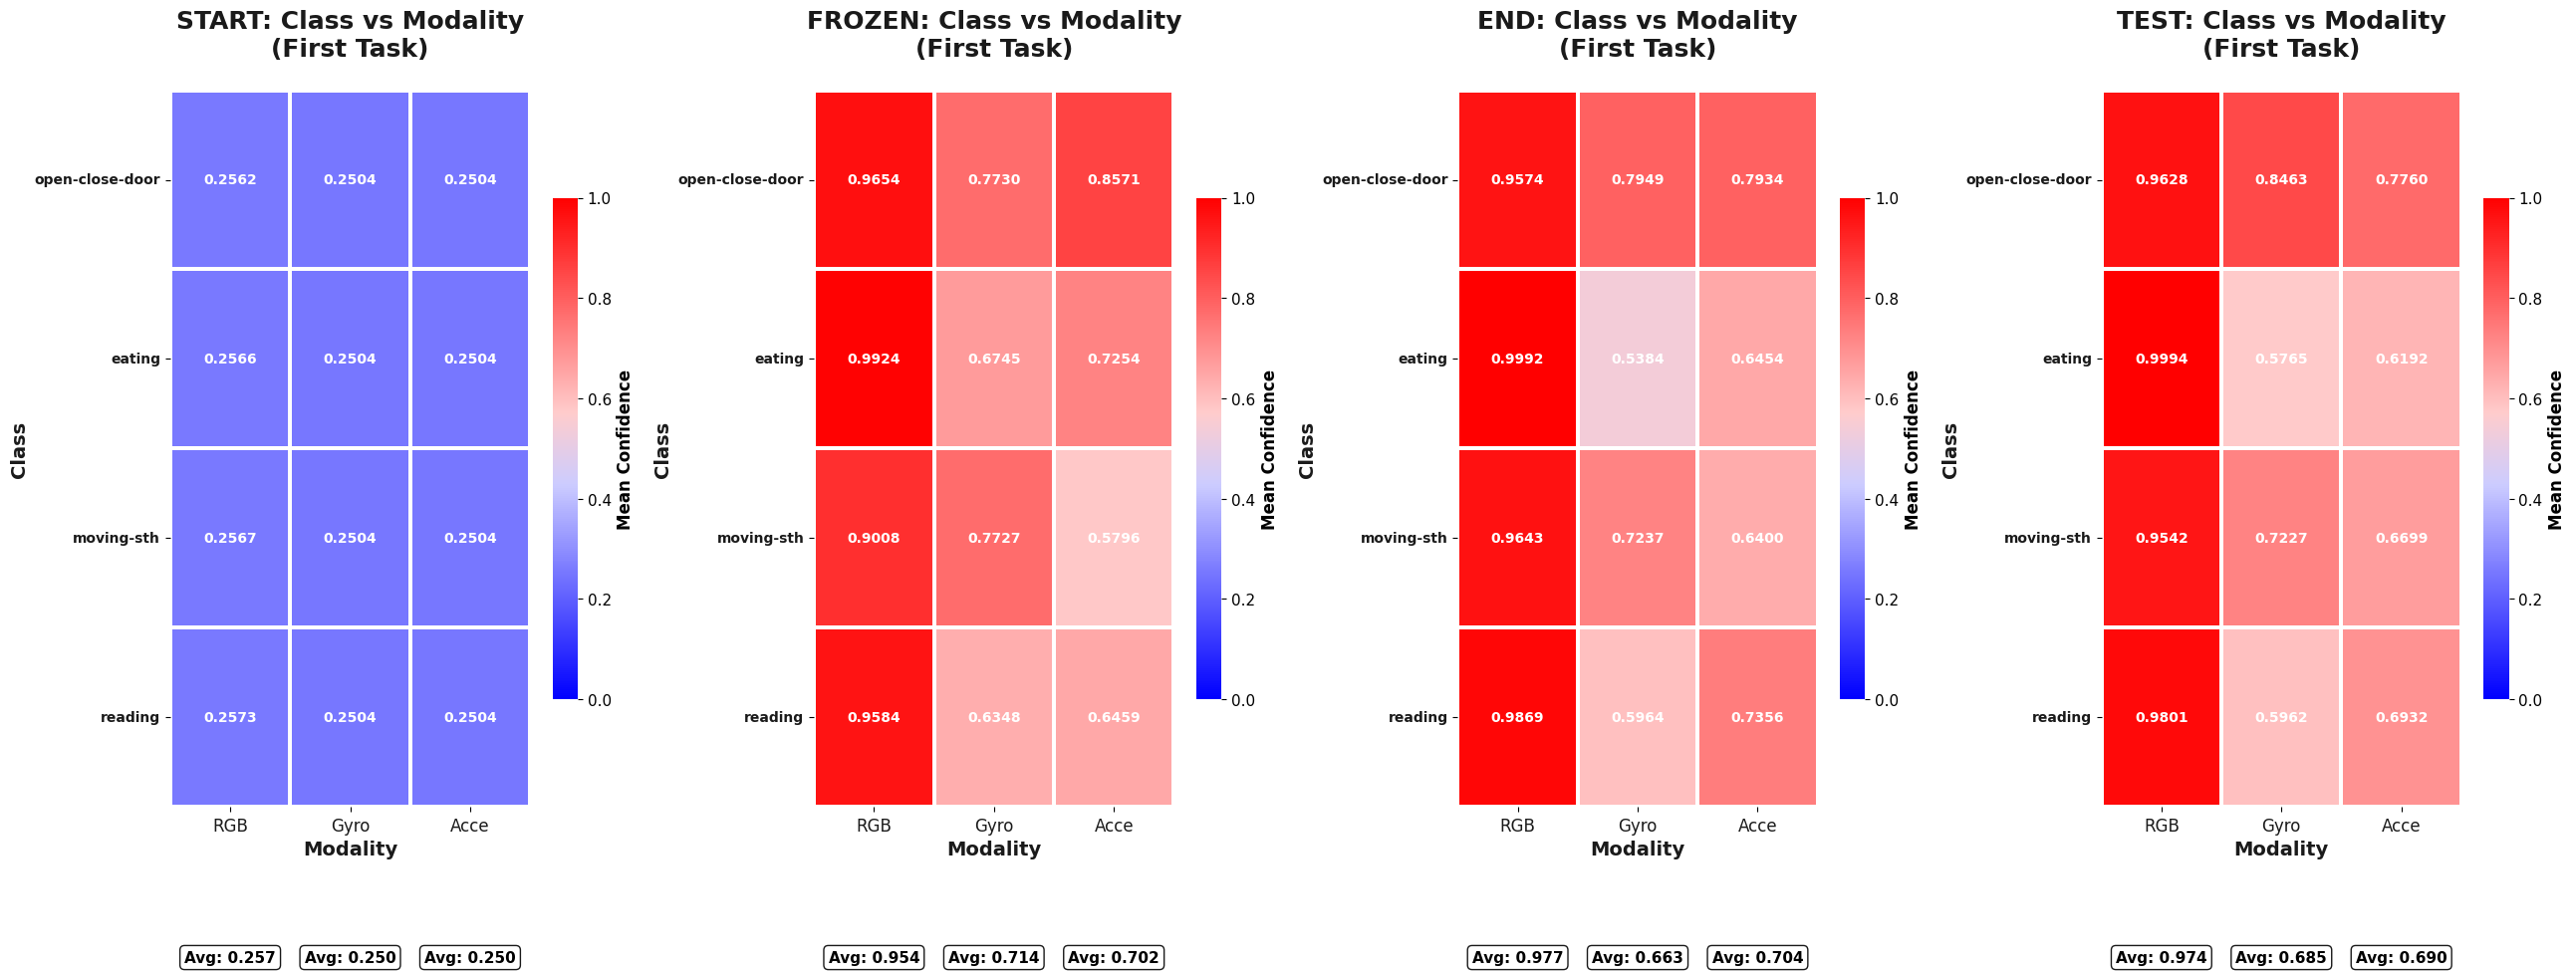

✅ 첫 번째 Task 히트맵 저장: first_task_heatmap.png


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(26, 10))
fig.patch.set_facecolor('white')

state_data_first = [
    ('START', df_start_first),
    ('FROZEN', df_frozen_first),
    ('END', df_end_first),
    ('TEST', df_test_first)
]

for idx, (state_name, df) in enumerate(state_data_first):
    ax = axes[idx]
    if len(df) > 0:
        df_with_names = df.copy()
        df_with_names.index = [class_to_activity[UESTC_MMEA_CLASS_ORDER[i]] for i in range(len(df))]
        
        im = sns.heatmap(
            df_with_names, annot=True, fmt='.4f', cmap=blue_red_cmap, ax=ax,
            cbar_kws={'label': 'Mean Confidence', 'shrink': 0.7},
            linewidths=1.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'}
        )
        
        ax.set_title(f'{state_name}: Class vs Modality\n(First Task)', 
                    fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
        ax.set_xlabel('Modality', fontsize=14, fontweight='bold', color='#1a1a1a')
        ax.set_ylabel('Class', fontsize=14, fontweight='bold', color='#1a1a1a')
        ax.set_xticklabels(df_with_names.columns, fontsize=12, color='#1a1a1a')
        ax.set_yticklabels(df_with_names.index, fontsize=10, fontweight='bold', color='#1a1a1a', rotation=0)
        
        cbar = im.collections[0].colorbar
        cbar.ax.tick_params(labelsize=11)
        cbar.set_label('Mean Confidence', fontsize=12, fontweight='bold')
        
        for i, modality in enumerate(df_with_names.columns):
            avg_val = df_with_names[modality].mean()
            ax.text(i + 0.5, len(df_with_names) + 0.8, f'Avg: {avg_val:.3f}', 
                   ha='center', va='top', fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    else:
        ax.text(0.5, 0.5, f'No Data\nfor {state_name}', 
               ha='center', va='center', fontsize=20, color='gray',
               transform=ax.transAxes)

plt.tight_layout()
plt.savefig('first_task_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ 첫 번째 Task 히트맵 저장: first_task_heatmap.png')

### 8.2 마지막 Task 히트맵 (All States)

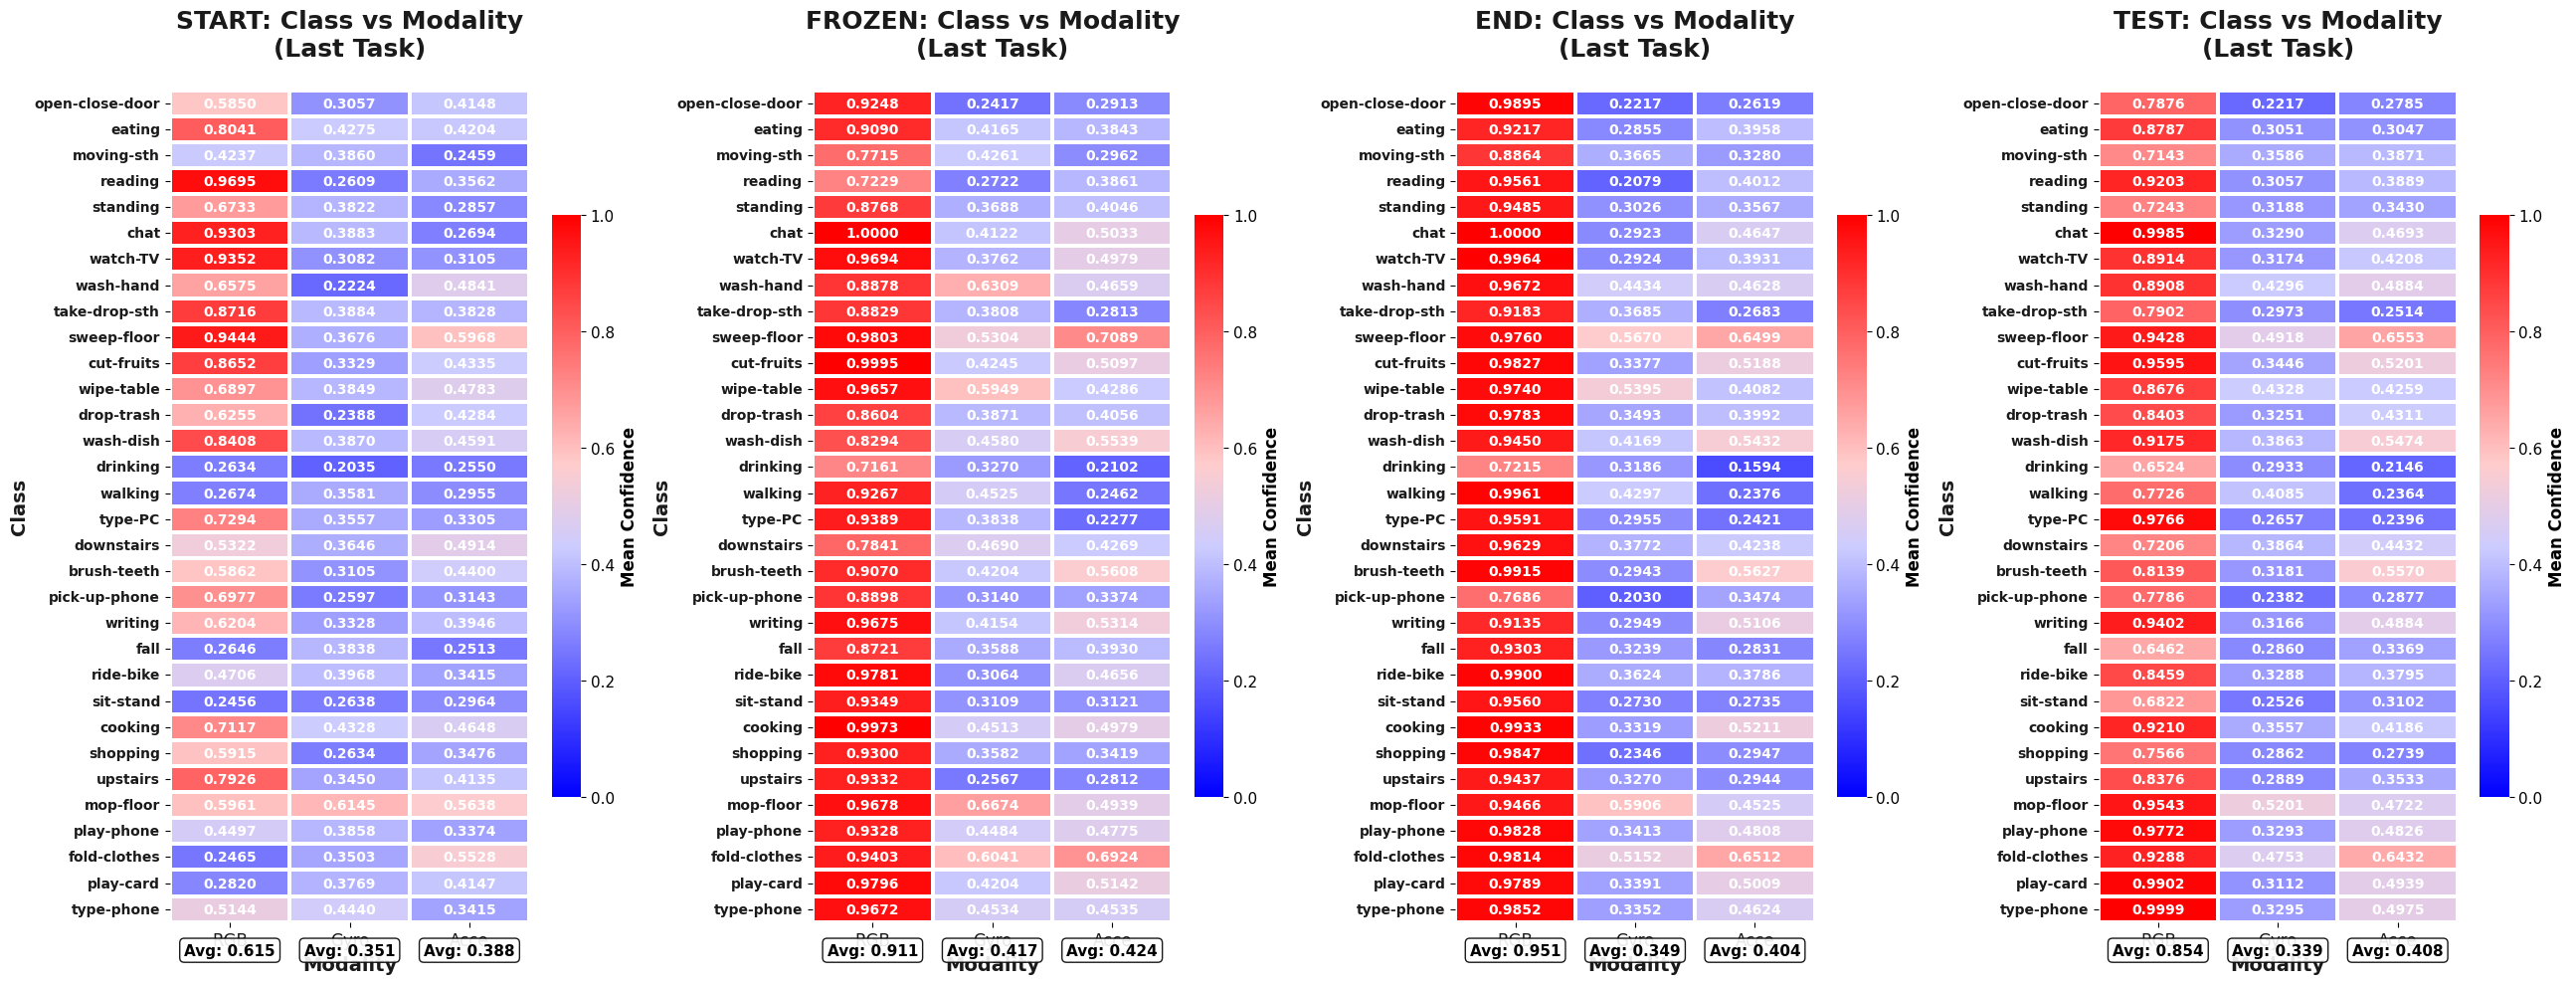

✅ 마지막 Task 히트맵 저장: last_task_heatmap.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(26, 10))
fig.patch.set_facecolor('white')

state_data_last = [
    ('START', df_start_final),
    ('FROZEN', df_frozen_final),
    ('END', df_end_final),
    ('TEST', df_test_final)
]

for idx, (state_name, df) in enumerate(state_data_last):
    ax = axes[idx]
    if len(df) > 0:
        df_with_names = df.copy()
        df_with_names.index = [class_to_activity[UESTC_MMEA_CLASS_ORDER[i]] for i in range(len(df))]
        
        im = sns.heatmap(
            df_with_names, annot=True, fmt='.4f', cmap=blue_red_cmap, ax=ax,
            cbar_kws={'label': 'Mean Confidence', 'shrink': 0.7},
            linewidths=1.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'}
        )
        
        ax.set_title(f'{state_name}: Class vs Modality\n(Last Task)', 
                    fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
        ax.set_xlabel('Modality', fontsize=14, fontweight='bold', color='#1a1a1a')
        ax.set_ylabel('Class', fontsize=14, fontweight='bold', color='#1a1a1a')
        ax.set_xticklabels(df_with_names.columns, fontsize=12, color='#1a1a1a')
        ax.set_yticklabels(df_with_names.index, fontsize=10, fontweight='bold', color='#1a1a1a', rotation=0)
        
        cbar = im.collections[0].colorbar
        cbar.ax.tick_params(labelsize=11)
        cbar.set_label('Mean Confidence', fontsize=12, fontweight='bold')
        
        for i, modality in enumerate(df_with_names.columns):
            avg_val = df_with_names[modality].mean()
            ax.text(i + 0.5, len(df_with_names) + 0.8, f'Avg: {avg_val:.3f}', 
                   ha='center', va='top', fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    else:
        ax.text(0.5, 0.5, f'No Data\nfor {state_name}', 
               ha='center', va='center', fontsize=20, color='gray',
               transform=ax.transAxes)

plt.tight_layout()
plt.savefig('last_task_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ 마지막 Task 히트맵 저장: last_task_heatmap.png')

### 8.3 첫 번째 Task - END & TEST만

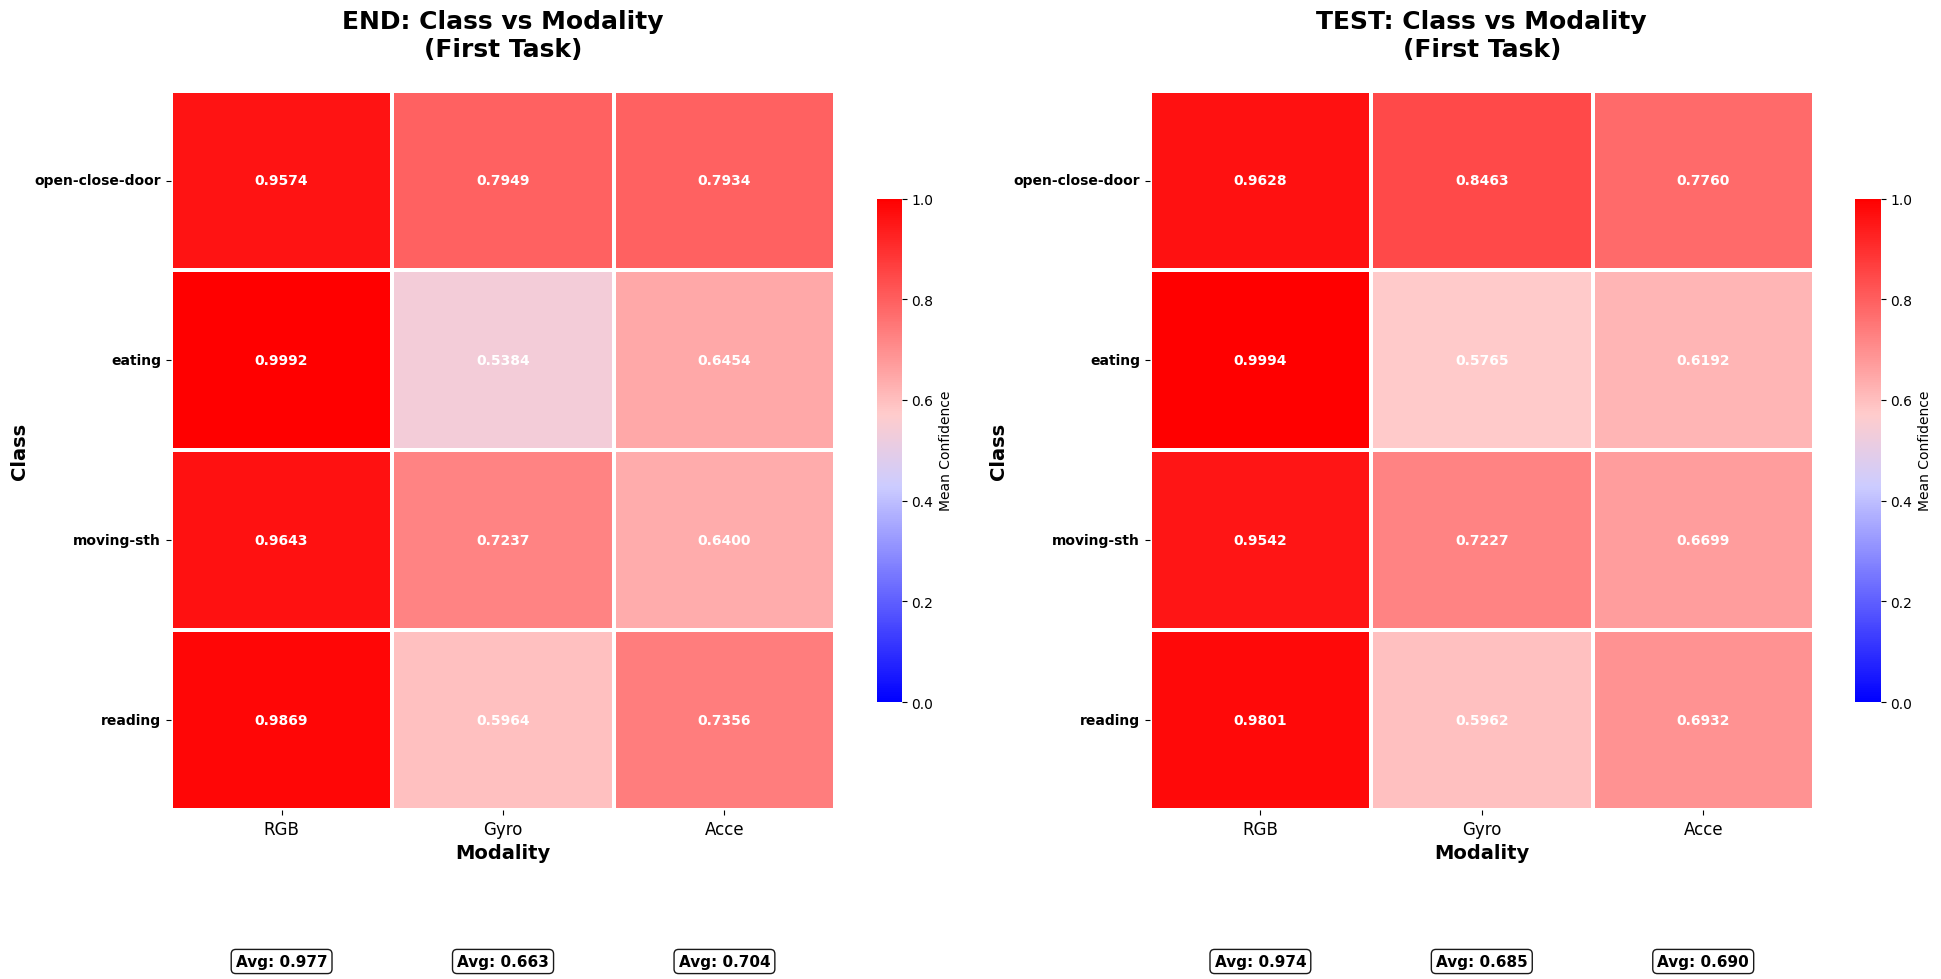

✅ 첫 번째 Task END & TEST 저장: first_task_end_test.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('white')

for idx, (state_name, df) in enumerate([('END', df_end_first), ('TEST', df_test_first)]):
    ax = axes[idx]
    if len(df) > 0:
        df_with_names = df.copy()
        df_with_names.index = [class_to_activity[UESTC_MMEA_CLASS_ORDER[i]] for i in range(len(df))]
        
        im = sns.heatmap(
            df_with_names, annot=True, fmt='.4f', cmap=blue_red_cmap, ax=ax,
            cbar_kws={'label': 'Mean Confidence', 'shrink': 0.7},
            linewidths=1.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'}
        )
        
        ax.set_title(f'{state_name}: Class vs Modality\n(First Task)', 
                    fontsize=18, fontweight='bold', pad=25)
        ax.set_xlabel('Modality', fontsize=14, fontweight='bold')
        ax.set_ylabel('Class', fontsize=14, fontweight='bold')
        ax.set_xticklabels(df_with_names.columns, fontsize=12)
        ax.set_yticklabels(df_with_names.index, fontsize=10, fontweight='bold', rotation=0)
        
        for i, modality in enumerate(df_with_names.columns):
            avg_val = df_with_names[modality].mean()
            ax.text(i + 0.5, len(df_with_names) + 0.8, f'Avg: {avg_val:.3f}', 
                   ha='center', va='top', fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('first_task_end_test.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ 첫 번째 Task END & TEST 저장: first_task_end_test.png')

### 8.4 마지막 Task - END & TEST만

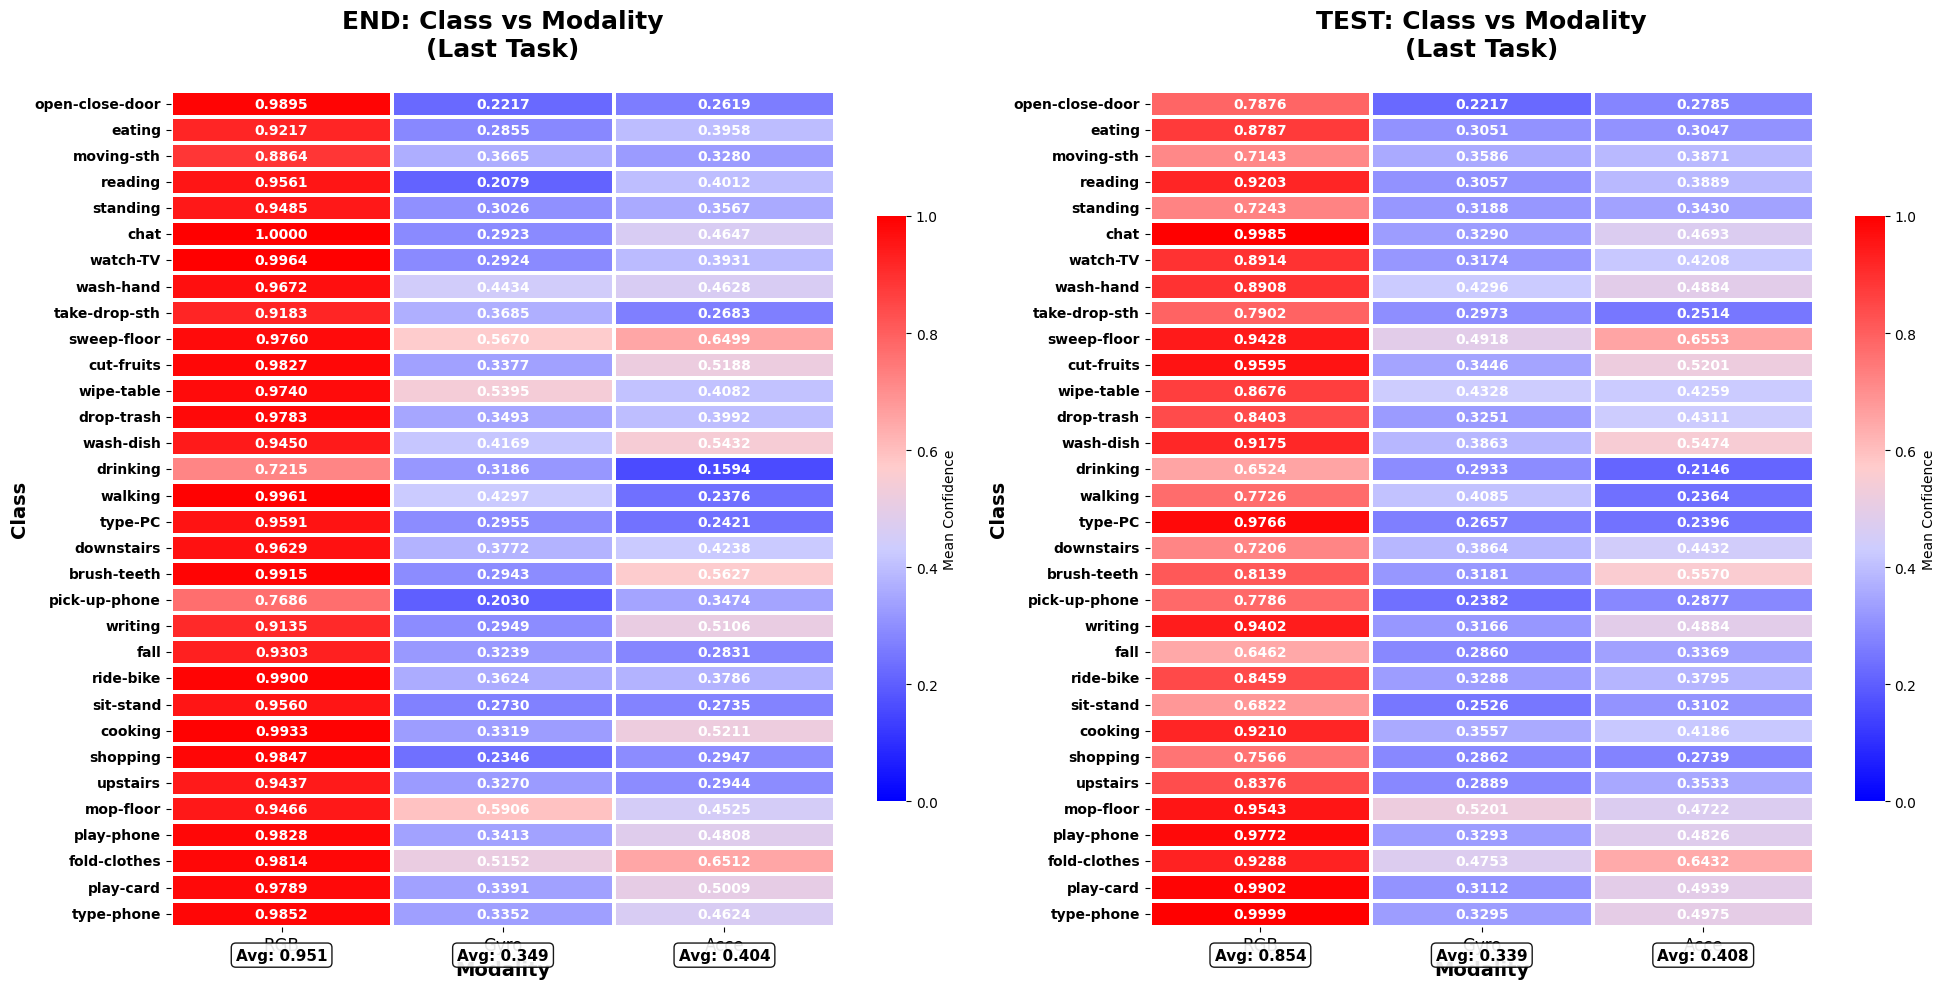

✅ 마지막 Task END & TEST 저장: last_task_end_test.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('white')

for idx, (state_name, df) in enumerate([('END', df_end_final), ('TEST', df_test_final)]):
    ax = axes[idx]
    if len(df) > 0:
        df_with_names = df.copy()
        df_with_names.index = [class_to_activity[UESTC_MMEA_CLASS_ORDER[i]] for i in range(len(df))]
        
        im = sns.heatmap(
            df_with_names, annot=True, fmt='.4f', cmap=blue_red_cmap, ax=ax,
            cbar_kws={'label': 'Mean Confidence', 'shrink': 0.7},
            linewidths=1.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'}
        )
        
        ax.set_title(f'{state_name}: Class vs Modality\n(Last Task)', 
                    fontsize=18, fontweight='bold', pad=25)
        ax.set_xlabel('Modality', fontsize=14, fontweight='bold')
        ax.set_ylabel('Class', fontsize=14, fontweight='bold')
        ax.set_xticklabels(df_with_names.columns, fontsize=12)
        ax.set_yticklabels(df_with_names.index, fontsize=10, fontweight='bold', rotation=0)
        
        for i, modality in enumerate(df_with_names.columns):
            avg_val = df_with_names[modality].mean()
            ax.text(i + 0.5, len(df_with_names) + 0.8, f'Avg: {avg_val:.3f}', 
                   ha='center', va='top', fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('last_task_end_test.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ 마지막 Task END & TEST 저장: last_task_end_test.png')